<a href="https://colab.research.google.com/github/keathansingh/Mental-health-detection/blob/main/Copy_of_mental_health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load your dataset
df = pd.read_csv("Combined Data.csv", quotechar='"', doublequote=True)  # Replace with your actual path

# Preview
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [ ]:
import re
# Redefine the cleaning function (no filtering by length)
def clean_text_keep_all(text):
    text = str(text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()  # Normalize whitespace
    return text

# Apply cleaning
df['statement'] = df['statement'].apply(clean_text_keep_all)

# Reset index
df = df.reset_index(drop=True)

# Save cleaned file if needed
df.to_csv('/content/cleaned_data.csv', index=False)

# Show cleaned sample including short texts
df.head(10)

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,trouble sleeping confused mind restless heart ...,Anxiety
2,2,All wrong back off dear forward doubt Stay in ...,Anxiety
3,3,Ive shifted my focus to something else but Im ...,Anxiety
4,4,Im restless and restless its been a month now ...,Anxiety
5,5,every break you must be nervous like something...,Anxiety
6,6,I feel scared anxious what can I do And may my...,Anxiety
7,7,Have you ever felt nervous but didnt know why,Anxiety
8,8,I havent slept well for days its like Im restl...,Anxiety
9,9,Im really worried I want to cry,Anxiety


In [ ]:
from os import rename
import numpy as np
from datetime import datetime, timedelta
import random

# Step 2.1: Generate synthetic user_id
num_users = 5000  # More users = more realistic tracking
df['user_id'] = np.random.choice([f'user_{i}' for i in range(num_users)], size=len(df))

# Step 2.2: Generate synthetic timestamps within a 2-week window
start_date = datetime.strptime("2024-01-01", "%Y-%m-%d")
end_date = start_date + timedelta(days=13)  # 2 weeks = 14 days

def random_date(start, end):
    delta = end - start
    return start + timedelta(days=random.randint(0, delta.days),
                             hours=random.randint(0, 23),
                             minutes=random.randint(0, 59))

df['timestamp'] = df['user_id'].apply(lambda x: random_date(start_date, end_date))
df['timestamp'] = pd.to_datetime(df['timestamp'])  # Ensure datetime format

# Optional: sort by user and timestamp for realism
df = df.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)

df = df.rename(columns={'Unnamed':'id','statement': 'text', 'status': 'label'})

df.head()


,Unnamed: 0,text,label,user_id,timestamp
0,13128,I have been doing well for the past few weeks ...,Depression,user_0,2024-01-05 00:25:00
1,38586,my mom called me disgusting for my dirty room ...,Depression,user_0,2024-01-05 21:08:00
2,15774,the past week I have spent every day crying in...,Depression,user_0,2024-01-06 10:02:00
3,13401,So it occurred to me today during my morning s...,Suicidal,user_0,2024-01-06 22:11:00
4,6820,check the condition of the battery and spark p...,Normal,user_0,2024-01-09 18:19:00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  53043 non-null  int64         
 1   text        53043 non-null  object        
 2   label       53043 non-null  object        
 3   user_id     53043 non-null  object        
 4   timestamp   53043 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 2.0+ MB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
text,0
label,0
user_id,0
timestamp,0


In [ ]:
df.columns

Index(['Unnamed: 0', 'text', 'label', 'user_id', 'timestamp'], dtype='object')

In [ ]:
df = df.dropna(subset=['text'])

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  53043 non-null  int64         
 1   text        53043 non-null  object        
 2   label       53043 non-null  object        
 3   user_id     53043 non-null  object        
 4   timestamp   53043 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 2.0+ MB


In [ ]:
df['label'].value_counts()

,count
label,
Normal,16351
Depression,15404
Suicidal,10653
Anxiety,3888
Bipolar,2877
Stress,2669
Personality disorder,1201


/tmp/ipython-input-665556490.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='Dark2')


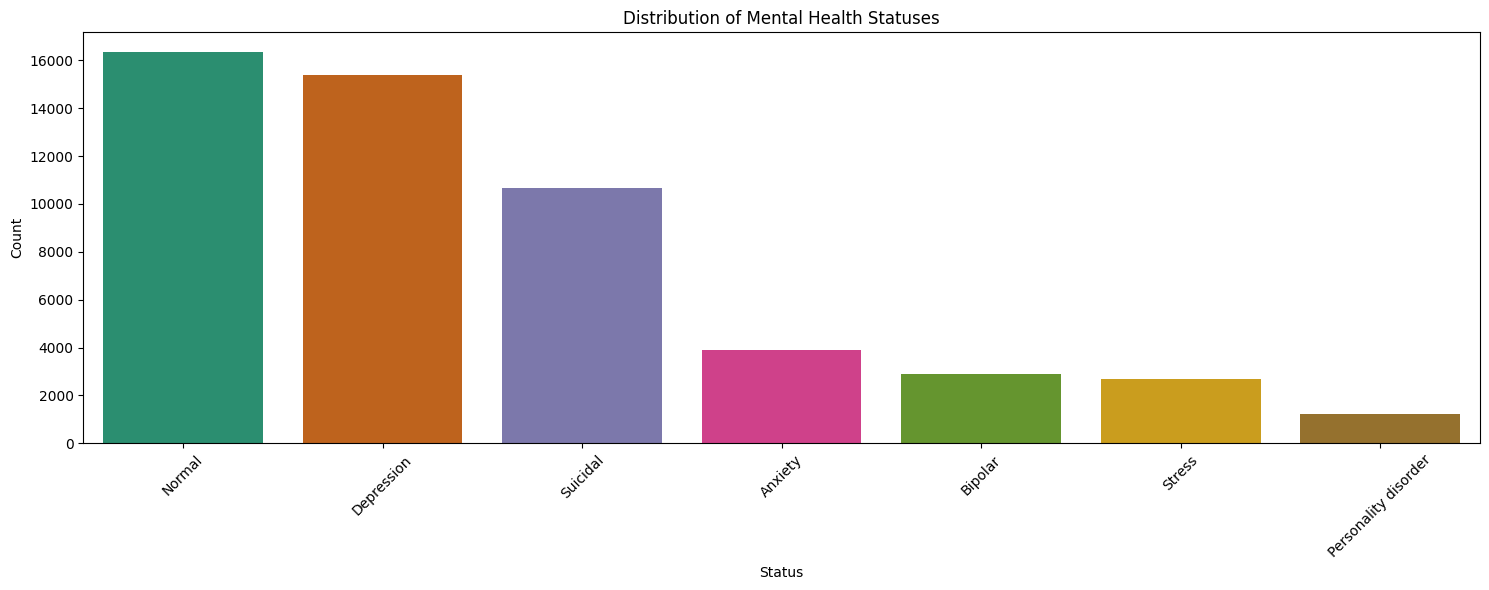

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='Dark2')

plt.title('Distribution of Mental Health Statuses')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/tmp/ipython-input-2765180074.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words_df, x='Word', y='Frequency', palette='gnuplot')


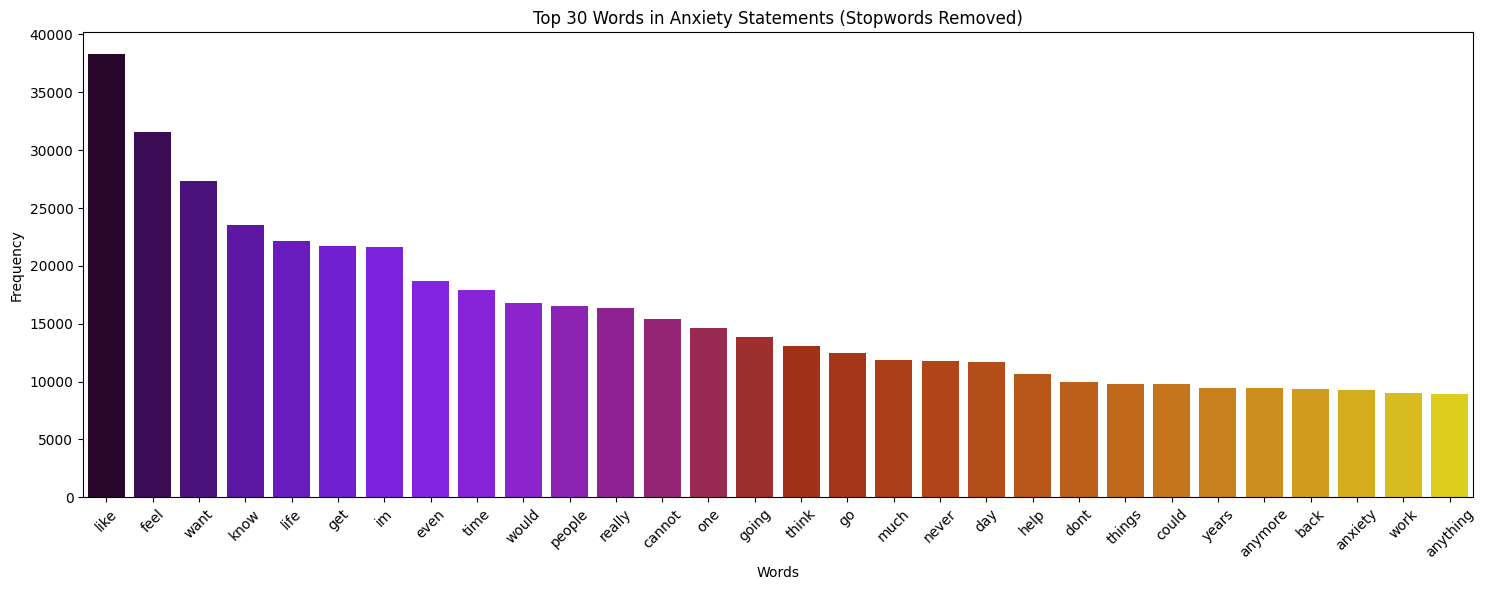

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

stopwords = set(stopwords.words('english'))
words = ' '.join(df['text']).split()
filtered_words = [word.lower() for word in words if word.lower() not in stopwords]

word_counts = Counter(filtered_words)
top_words = dict(sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:30])

top_words_df = pd.DataFrame(list(top_words.items()), columns=['Word', 'Frequency'])
plt.figure(figsize=(15, 6))
sns.barplot(data=top_words_df, x='Word', y='Frequency', palette='gnuplot')
plt.title('Top 30 Words in Anxiety Statements (Stopwords Removed)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode string labels to integers
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# Save mapping for later use
label_map = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Encoding Map:", label_map)


Label Encoding Map: {'Anxiety': np.int64(0), 'Bipolar': np.int64(1), 'Depression': np.int64(2), 'Normal': np.int64(3), 'Personality disorder': np.int64(4), 'Stress': np.int64(5), 'Suicidal': np.int64(6)}


In [ ]:
from datasets import Dataset

# Select only needed columns for model
dataset = Dataset.from_pandas(df[['text', 'label_encoded', 'user_id', 'timestamp']])
dataset = dataset.rename_column("label_encoded", "label")

# Split into train/test (80-20)
dataset = dataset.train_test_split(test_size=0.2)
train_dataset = dataset['train']
test_dataset = dataset['test']


In [ ]:
 # Transformers installation
! pip install transformers
# To install from source instead of the last release, comment the command above and uncomment the following one.
#! pip install git+https://github.com/huggingface/transformers.git

In [ ]:
!pip install -U transformers

In [ ]:
from transformers import pipeline

In [ ]:
from transformers import AutoTokenizer

model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(example):
    return tokenizer(example["text"], padding="max_length", truncation=True,max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/42434 [00:00<?, ? examples/s]

Map:   0%|          | 0/10609 [00:00<?, ? examples/s]

In [ ]:
# Set format so Trainer can use it with PyTorch tensors
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


In [ ]:
from transformers import AutoModelForSequenceClassification

num_labels = len(label_encoder.classes_)  # Number of unique mental health classes

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


In [ ]:
import evaluate

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return accuracy.compute(predictions=predictions, references=labels)


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",                  # Where to save model
    eval_strategy="epoch",            # Evaluate after every epoch
    save_strategy="epoch",                  # Save after every epoch
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,                     # You can increase for better performance
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir="./logs",
    logging_steps=10,
    fp16=True,
    report_to="none"                        # Disable W&B if you aren't using it
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Start training
trainer.train()


/tmp/ipython-input-1731676156.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.579000,0.449273,0.822415
2,0.407600,0.515964,0.815722
3,0.259200,0.593333,0.814026
4,0.181100,0.788575,0.817608


Epoch,Training Loss,Validation Loss,Accuracy
1,0.579000,0.449273,0.822415
2,0.407600,0.515964,0.815722
3,0.259200,0.593333,0.814026
4,0.181100,0.788575,0.817608
5,0.174500,0.971690,0.812141
6,0.060000,1.122056,0.818927
7,0.008300,1.217227,0.818739
8,0.013000,1.260942,0.817985


TrainOutput(global_step=21224, training_loss=0.17490544722405327, metrics={'train_runtime': 3086.1832, 'train_samples_per_second': 109.997, 'train_steps_per_second': 6.877, 'total_flos': 2.23307114935296e+16, 'train_loss': 0.17490544722405327, 'epoch': 8.0})

In [ ]:
metrics = trainer.evaluate()
print("Evaluation Metrics:", metrics)

Evaluation Metrics: {'eval_loss': 0.44927293062210083, 'eval_accuracy': 0.8224149307192007, 'eval_runtime': 31.443, 'eval_samples_per_second': 337.404, 'eval_steps_per_second': 21.118, 'epoch': 8.0}


In [ ]:
import torch

In [ ]:
def predict_text(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
        predicted_class = torch.argmax(outputs.logits, dim=1).item()
        predicted_label = label_encoder.inverse_transform([predicted_class])[0]
        return predicted_label

# Test examples
print(predict_text("I feel so overwhelmed and anxious."))
print(predict_text("Life is good. I'm feeling happy today."))
print(predict_text("I want to end it all."))
print(predict_text("I feel like everyone would be better off without me."))
print(predict_text("i would like to tast it"))

Anxiety
Normal
Suicidal
Suicidal
Normal


In [ ]:
from sklearn.metrics import classification_report
import numpy as np
import torch

# Assuming 'trainer' and 'test_dataset' are already defined and trained
# Get predictions from the test set
predictions = trainer.predict(test_dataset)

# Extract true labels and predicted labels
all_labels = predictions.label_ids
all_preds = np.argmax(predictions.predictions, axis=1)

# Generate and print the classification report
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

                      precision    recall  f1-score   support

             Anxiety       0.86      0.86      0.86       790
             Bipolar       0.88      0.80      0.83       581
          Depression       0.79      0.76      0.77      3105
              Normal       0.95      0.95      0.95      3266
Personality disorder       0.67      0.71      0.69       238
              Stress       0.74      0.67      0.70       529
            Suicidal       0.70      0.76      0.73      2100

            accuracy                           0.82     10609
           macro avg       0.80      0.79      0.79     10609
        weighted avg       0.82      0.82      0.82     10609



Accuracy: 0.8224149307192007
                      precision    recall  f1-score   support

             Anxiety       0.86      0.86      0.86       790
             Bipolar       0.88      0.80      0.83       581
          Depression       0.79      0.76      0.77      3105
              Normal       0.95      0.95      0.95      3266
Personality disorder       0.67      0.71      0.69       238
              Stress       0.74      0.67      0.70       529
            Suicidal       0.70      0.76      0.73      2100

            accuracy                           0.82     10609
           macro avg       0.80      0.79      0.79     10609
        weighted avg       0.82      0.82      0.82     10609



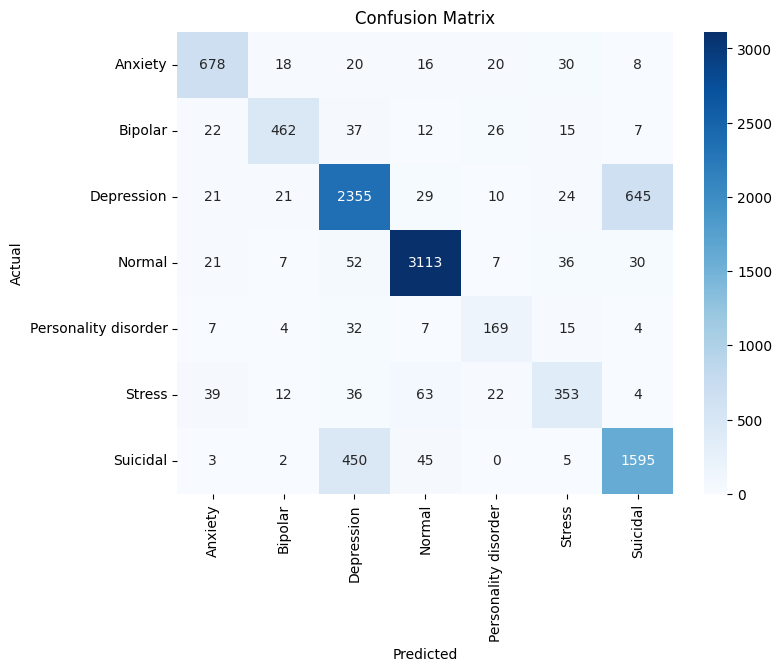

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns


model.eval()

# Get predictions from the test set using the trainer
predictions = trainer.predict(test_dataset)

# Extract true labels and predicted labels
all_labels = predictions.label_ids
all_preds = np.argmax(predictions.predictions, axis=1)

# Print Accuracy Score
print("Accuracy:", accuracy_score(all_labels, all_preds))

# Generate and print the classification report
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

# Generate and plot the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_) # Use label_encoder.classes_ for labels
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

import matplotlib.pyplot as plt

# Data from the provided table
epochs = list(range(1, 11))
training_loss = [0.491200, 0.445100, 0.224600, 0.102300, 0.149200,
                 0.075300, 0.109900, 0.067700, 0.000300, 0.008400]
validation_loss = [0.524464, 0.460557, 0.521745, 0.706179, 0.847970,
                   1.072334, 1.142660, 1.200051, 1.273623, 1.338413]

# Plotting the line graph
plt.figure(figsize=(8,6))
plt.plot(epochs, training_loss, marker='o', color='blue', label='Training Loss')
plt.plot(epochs, validation_loss, marker='o', color='red', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save as image
output_path = "/mnt/data/training_vs_validation_loss.png"
plt.savefig(output_path, dpi=300)
plt.close()

output_path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
torch.save(model.state_dict(), "model.pth")
